In [1]:
# Install Score-CAM library (only needed for the explainability cells)
!pip install grad-cam -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Core imports + reproducibility seed + global config
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_ROOT = "/kaggle/input/datasets/ashery/chexpert/"
disease_cols = ["Cardiomegaly", "Edema", "Pleural Effusion"]
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
PATIENCE = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
df = pd.read_csv(os.path.join(DATA_ROOT, "train.csv"))
df[disease_cols] = df[disease_cols].replace(-1, 0).fillna(0)   # U-Zeros policy
df = df[df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)
df["patient_id"] = df["Path"].str.extract(r"(patient\d+)")

print("Total frontal images after cleaning:", len(df))
print(df[disease_cols].sum())

Total frontal images after cleaning: 191027
Cardiomegaly        23385.0
Edema               49675.0
Pleural Effusion    76899.0
dtype: float64


In [4]:
N_PER_DISEASE = 6000
selected_indices = set()
for d in disease_cols:
    pos = df[df[d] == 1].index.tolist()
    selected_indices.update(np.random.choice(pos, size=min(N_PER_DISEASE, len(pos)), replace=False))

# True-negative pool: images negative on all 3 target diseases. Without this, every
# selected image is positive for at least one disease, which inflates positive prevalence
# well above the natural CheXpert rate and leaves specificity on healthy patients untested.
neg_mask = (df[disease_cols] == 0).all(axis=1)
neg_all = df[neg_mask].index.tolist()
selected_indices.update(np.random.choice(neg_all, size=min(N_PER_DISEASE, len(neg_all)), replace=False))

df_balanced = df.loc[list(selected_indices)].reset_index(drop=True)
df_balanced["full_path"] = df_balanced["Path"].str.replace("CheXpert-v1.0-small/", DATA_ROOT, regex=False)

print("Balanced subsample size:", len(df_balanced))
print("Unique patients in subsample:", df_balanced['patient_id'].nunique())

Balanced subsample size: 23216
Unique patients in subsample: 15725


In [5]:
patients = df_balanced["patient_id"].unique()
np.random.shuffle(patients)
n_train = int(0.70 * len(patients))
n_val = int(0.85 * len(patients))
train_patients = patients[:n_train]
val_patients = patients[n_train:n_val]
test_patients = patients[n_val:]

train_df = df_balanced[df_balanced.patient_id.isin(train_patients)].reset_index(drop=True)
val_df = df_balanced[df_balanced.patient_id.isin(val_patients)].reset_index(drop=True)
test_df = df_balanced[df_balanced.patient_id.isin(test_patients)].reset_index(drop=True)

# Sanity check #1: confirm zero patient overlap across splits (must print True/True/True)
print("No patient overlap train/val:", len(set(train_patients) & set(val_patients)) == 0)
print("No patient overlap train/test:", len(set(train_patients) & set(test_patients)) == 0)
print("No patient overlap val/test:", len(set(val_patients) & set(test_patients)) == 0)

print("\nTrain / Val / Test image counts:", len(train_df), len(val_df), len(test_df))
print("Train / Val / Test patient counts:", len(train_patients), len(val_patients), len(test_patients))

No patient overlap train/val: True
No patient overlap train/test: True
No patient overlap val/test: True

Train / Val / Test image counts: 16230 3415 3571
Train / Val / Test patient counts: 11007 2359 2359


In [6]:
# Sanity check #2: per-disease class balance in each split.
# This is the number every technique's threshold-tuning and F1/AUC will be judged against —
# check it once here so any surprising result later can be traced back to data, not a bug.
for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"--- {name} (n={len(split_df)}) ---")
    for d in disease_cols:
        pos = int(split_df[d].sum())
        print(f"  {d:20s} pos={pos:4d}  neg={len(split_df)-pos:4d}  pos_ratio={pos/len(split_df):.3f}")

--- Train (n=16230) ---
  Cardiomegaly         pos=5288  neg=10942  pos_ratio=0.326
  Edema                pos=7022  neg=9208  pos_ratio=0.433
  Pleural Effusion     pos=7700  neg=8530  pos_ratio=0.474
--- Val (n=3415) ---
  Cardiomegaly         pos=1056  neg=2359  pos_ratio=0.309
  Edema                pos=1478  neg=1937  pos_ratio=0.433
  Pleural Effusion     pos=1636  neg=1779  pos_ratio=0.479
--- Test (n=3571) ---
  Cardiomegaly         pos=1169  neg=2402  pos_ratio=0.327
  Edema                pos=1581  neg=1990  pos_ratio=0.443
  Pleural Effusion     pos=1748  neg=1823  pos_ratio=0.489


In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = cv2.imread(row["full_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        img = self.transform(img)
        labels = torch.tensor([row[d] for d in disease_cols], dtype=torch.float32)
        return img, labels

train_loader = DataLoader(ChestXrayDataset(train_df, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ChestXrayDataset(val_df, transform), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ChestXrayDataset(test_df, transform), batch_size=BATCH_SIZE, shuffle=False)

print("Batches -- train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))

Batches -- train: 508 val: 107 test: 112


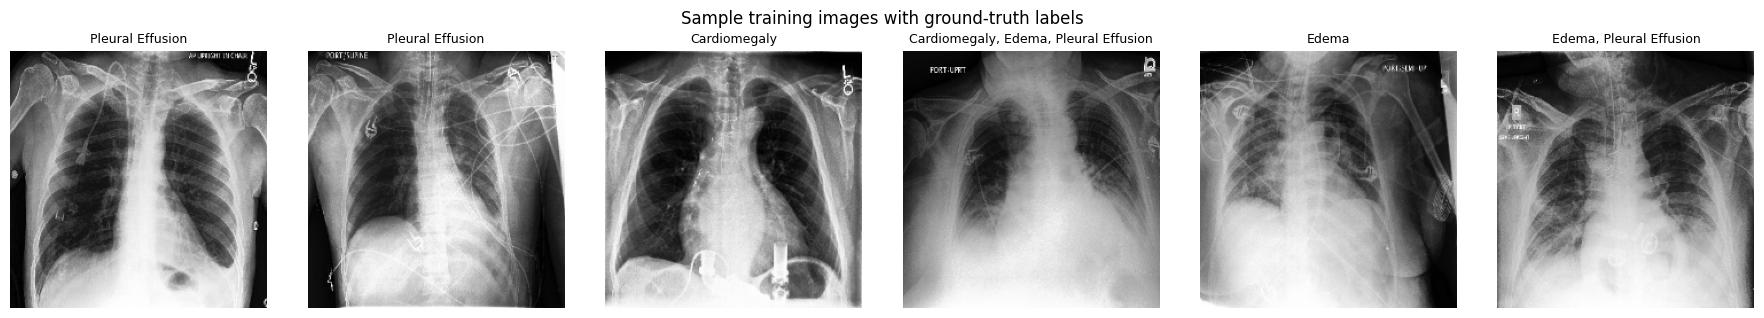

In [8]:
# Visual sanity check: a batch of training images with their ground-truth labels.
def denorm(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
for i in range(6):
    axes[i].imshow(denorm(images[i]))
    present = [disease_cols[j] for j in range(3) if labels[i, j] == 1]
    axes[i].set_title(", ".join(present) if present else "No finding", fontsize=9)
    axes[i].axis("off")
plt.suptitle("Sample training images with ground-truth labels")
plt.tight_layout()
plt.show()


In [9]:
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2017) — down-weights easy, already-confident examples via the
    (1-pt)^gamma focusing term, and applies alpha_t = alpha*y + (1-alpha)*(1-y) to weight
    positive and negative examples differently. Used only by the 'matched recipe' (Techniques
    2, 3, 4) -- Technique 1 uses plain BCE to match the published CheXNet recipe exactly."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        return (alpha_t * (1 - pt) ** self.gamma * bce).mean()


def train_model(model, criterion, optimizer, scheduler, tag, forward_fn=None):
    """Identical training loop for every technique. Returns the best (early-stopped) model
    plus the per-epoch loss history, so a loss curve can be plotted for every technique in
    exactly the same way."""
    forward_fn = forward_fn or (lambda m, x: m(x))
    best_val_loss = float("inf")
    counter = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(forward_fn(model, imgs), lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                val_loss += criterion(forward_fn(model, imgs), lbls).item()
        val_loss /= len(val_loader)
        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{tag}] epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"best_{tag}.pth")
            counter = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"[{tag}] early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(f"best_{tag}.pth", map_location=device))
    return model, history


def plot_loss_curve(history, tag):
    """Same loss-curve plotting call used after every technique's training."""
    plt.figure(figsize=(5, 3.5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"[{tag}] Train vs Val Loss")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, tag, forward_fn=None):
    """Tunes per-disease thresholds on val_loader only, reports on test_loader only.
    Identical protocol for every model -- this function is never modified per-model."""
    forward_fn = forward_fn or (lambda m, x: m(x))
    model.eval()

    val_probs, val_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            probs = torch.sigmoid(forward_fn(model, imgs.to(device)))
            val_probs.append(probs.cpu().numpy())
            val_labels.append(lbls.numpy())
    val_probs, val_labels = np.concatenate(val_probs), np.concatenate(val_labels)

    thresholds = []
    for i in range(len(disease_cols)):
        p, r, t = precision_recall_curve(val_labels[:, i], val_probs[:, i])
        f1s_curve = 2 * p * r / (p + r + 1e-8)
        best = f1s_curve.argmax()
        thresholds.append(float(t[best]) if best < len(t) else 0.5)
        print(f"[{tag}] {disease_cols[i]}: threshold tuned on VAL = {thresholds[-1]:.3f}")

    test_probs, test_labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            probs = torch.sigmoid(forward_fn(model, imgs.to(device)))
            test_probs.append(probs.cpu().numpy())
            test_labels.append(lbls.numpy())
    test_probs, test_labels = np.concatenate(test_probs), np.concatenate(test_labels)

    f1s, aucs, precisions, recalls, supports = [], [], [], [], []
    for i, d in enumerate(disease_cols):
        y_true = test_labels[:, i].astype(int)          # int dtype required for classification_report key lookup
        preds = (test_probs[:, i] > thresholds[i]).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        try:
            auc = roc_auc_score(y_true, test_probs[:, i])
        except ValueError:
            auc = float("nan")
        report = classification_report(y_true, preds, output_dict=True, zero_division=0)
        f1s.append(f1)
        aucs.append(auc)
        precisions.append(report["1"]["precision"] if "1" in report else float("nan"))
        recalls.append(report["1"]["recall"] if "1" in report else float("nan"))
        supports.append(int(y_true.sum()))

    result = pd.DataFrame({
        "Disease": disease_cols, "Precision": precisions, "Recall": recalls,
        "F1": f1s, "AUC": aucs, "Test positives": supports,
    })
    print(f"\n=== {tag}: TEST SET report (thresholds tuned on VAL only) ===")
    print(result.to_string(index=False))
    return f1s, aucs, thresholds, test_probs, test_labels

In [10]:
def generate_sample_report(forward_fn, model, image_tensor, true_labels, thresholds, tag, rgb_image=None):
    """Clean, clinically-styled diagnostic report for ONE image: probability, decision
    threshold, predicted status, and ground truth per disease. Same function is reused for
    every technique so the output format is directly comparable across all 4."""
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(forward_fn(model, image_tensor.unsqueeze(0).to(device)))[0].cpu().numpy()

    print(f"\n=== Chest X-ray Diagnostic Report [{tag}] ===")
    for i, d in enumerate(disease_cols):
        pred = "POSITIVE" if probs[i] > thresholds[i] else "negative"
        truth = "POSITIVE" if true_labels[i] == 1 else "negative"
        match = "match" if (probs[i] > thresholds[i]) == (true_labels[i] == 1) else "MISMATCH"
        print(f"  {d:20s} prob={probs[i]*100:5.1f}%  threshold={thresholds[i]:.2f}  "
              f"predicted={pred:8s}  ground_truth={truth:8s}  [{match}]")

    if rgb_image is not None:
        plt.figure(figsize=(3.5, 3.5))
        plt.imshow(rgb_image)
        plt.title(f"[{tag}] sample input")
        plt.axis("off")
        plt.show()

In [11]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def score_cam_per_disease(model_for_cam, target_layer, input_tensor, rgb_image, tag,
                           ground_truth, thresholds, forward_fn=lambda m, x: m(x)):
    """Generates ONE independent Score-CAM heatmap PER DISEASE, with ground truth and
    model prediction shown in each subplot title."""
    cam = ScoreCAM(model=model_for_cam, target_layers=[target_layer])

    with torch.no_grad():
        probs = torch.sigmoid(forward_fn(model_for_cam, input_tensor))[0].cpu().numpy()

    fig, axes = plt.subplots(1, len(disease_cols) + 1, figsize=(4 * (len(disease_cols) + 1), 4))
    axes[0].imshow(rgb_image); axes[0].set_title("Input"); axes[0].axis("off")

    for i, d in enumerate(disease_cols):
        grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(i)])[0]
        print(f"[{tag}] {d}: min={grayscale_cam.min():.4f} max={grayscale_cam.max():.4f} mean={grayscale_cam.mean():.4f}")
        cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)
        axes[i + 1].imshow(cam_image)

        pred = int(probs[i] >= thresholds[i])
        gt = int(ground_truth[i])
        flag = "OK" if pred == gt else "X"
        axes[i + 1].set_title(f"{d}\npred={pred} (p={probs[i]:.2f}) gt={gt} [{flag}]", fontsize=9)
        axes[i + 1].axis("off")

    plt.suptitle(f"[{tag}] Independent per-disease Score-CAM heatmaps")
    plt.tight_layout()
    plt.show()

In [12]:
# Two fixed sample images reused across all 4 techniques' heatmap cells:
# SAMPLE A = all 3 diseases positive, SAMPLE B = exactly 1 disease positive.
label_sums = test_df[disease_cols].sum(axis=1)

all_pos_candidates = test_df[label_sums == 3].index.tolist()
one_pos_candidates = test_df[label_sums == 1].index.tolist()

assert len(all_pos_candidates) > 0, "No all-positive image found in test_df"
assert len(one_pos_candidates) > 0, "No single-positive image found in test_df"

IDX_ALL_POS = all_pos_candidates[0]
IDX_ONE_POS = one_pos_candidates[0]

def load_sample(idx):
    row = test_df.iloc[idx]
    img = cv2.imread(row["full_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    tensor = transform(img)
    labels = np.array([row[d] for d in disease_cols], dtype=np.float32)
    return tensor.unsqueeze(0).to(device), tensor, labels, denorm(tensor)

sampleA_input_tensor, sampleA_image_tensor, sampleA_true_labels, sampleA_rgb_image = load_sample(IDX_ALL_POS)
sampleB_input_tensor, sampleB_image_tensor, sampleB_true_labels, sampleB_rgb_image = load_sample(IDX_ONE_POS)

print("SAMPLE A (all positive) ground truth:", {disease_cols[i]: int(sampleA_true_labels[i]) for i in range(3)})
print("SAMPLE B (one positive) ground truth:", {disease_cols[i]: int(sampleB_true_labels[i]) for i in range(3)})

SAMPLE A (all positive) ground truth: {'Cardiomegaly': 1, 'Edema': 1, 'Pleural Effusion': 1}
SAMPLE B (one positive) ground truth: {'Cardiomegaly': 0, 'Edema': 1, 'Pleural Effusion': 0}


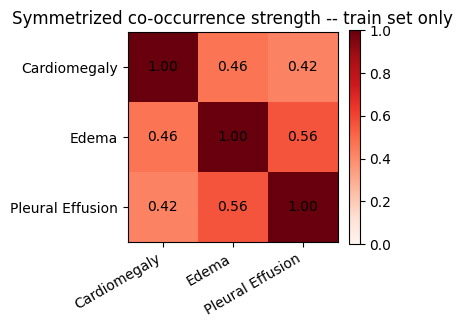

In [13]:
label_matrix = train_df[disease_cols].values.astype(np.float32)
co_occurrence = label_matrix.T @ label_matrix
diag = np.diag(co_occurrence).copy()
diag[diag == 0] = 1.0
adjacency = co_occurrence / diag[:, None]          # P(col disease | row disease) -- directed
adjacency = (adjacency + adjacency.T) / 2          # symmetrize before spectral normalization,
                                                    # since D^-1/2 A D^-1/2 assumes an undirected graph

adjacency_with_self_loops = adjacency + np.eye(len(disease_cols), dtype=np.float32)
degree = adjacency_with_self_loops.sum(axis=1)
D_inv_sqrt = np.diag(np.power(degree, -0.5))
adjacency_norm = torch.tensor(D_inv_sqrt @ adjacency_with_self_loops @ D_inv_sqrt, dtype=torch.float32).to(device)

# Stage 4 output (a): co-occurrence matrix, built from TRAIN split only
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(adjacency, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(len(disease_cols))); ax.set_xticklabels(disease_cols, rotation=30, ha="right")
ax.set_yticks(range(len(disease_cols))); ax.set_yticklabels(disease_cols)
for i in range(len(disease_cols)):
    for j in range(len(disease_cols)):
        ax.text(j, i, f"{adjacency[i,j]:.2f}", ha="center", va="center")
ax.set_title("Symmetrized co-occurrence strength -- train set only")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

In [14]:
class GraphConvolution(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = nn.Linear(in_f, out_f, bias=False)

    def forward(self, x, adj):
        return adj @ self.weight(x)


class CheXGCN(nn.Module):
    def __init__(self, num_labels, feature_dim=1024, label_embed_dim=300, gcn_hidden=512, dropout=0.3):
        super().__init__()
        self.backbone = models.densenet121(weights="DEFAULT").features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.label_embeddings = nn.Parameter(torch.randn(num_labels, label_embed_dim) * 0.01)
        self.gcn1 = GraphConvolution(label_embed_dim, gcn_hidden)
        self.gcn2 = GraphConvolution(gcn_hidden, feature_dim)

    def forward(self, x, adj):
        feat = F.relu(self.backbone(x))
        feat = self.dropout(self.pool(feat).flatten(1))
        label_repr = F.relu(self.gcn1(self.label_embeddings, adj))
        label_repr = self.gcn2(label_repr, adj)
        return feat @ label_repr.T


def gcn_forward(m, x):
    return m(x, adjacency_norm)

In [15]:
import os
print(os.listdir("/kaggle/input/models/suryasampreethchirla/6k-chexgcn/pytorch/default/1"))

['best_chexgcn.pth']


In [16]:
model_chexgcn = CheXGCN(num_labels=len(disease_cols)).to(device)
model_chexgcn.load_state_dict(torch.load(
    "/kaggle/input/models/suryasampreethchirla/6k-chexgcn/pytorch/default/1/best_chexgcn.pth",
    map_location=device
))
model_chexgcn.eval()
print("CheXGCN weights loaded.")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 239MB/s]


CheXGCN weights loaded.


In [17]:
# Stage 4 output (c): held-out test metrics
chexgcn_f1, chexgcn_auc, chexgcn_thresholds, chexgcn_test_probs, chexgcn_test_labels = \
    evaluate_model(model_chexgcn, "CheXGCN", forward_fn=gcn_forward)

[CheXGCN] Cardiomegaly: threshold tuned on VAL = 0.382
[CheXGCN] Edema: threshold tuned on VAL = 0.377
[CheXGCN] Pleural Effusion: threshold tuned on VAL = 0.379

=== CheXGCN: TEST SET report (thresholds tuned on VAL only) ===
         Disease  Precision   Recall       F1      AUC  Test positives
    Cardiomegaly   0.600137 0.751069 0.667173 0.829473            1169
           Edema   0.630332 0.841240 0.720672 0.803842            1581
Pleural Effusion   0.712494 0.844966 0.773096 0.842030            1748



=== Chest X-ray Diagnostic Report [CheXGCN - all positive] ===
  Cardiomegaly         prob= 40.9%  threshold=0.38  predicted=POSITIVE  ground_truth=POSITIVE  [match]
  Edema                prob= 44.5%  threshold=0.38  predicted=POSITIVE  ground_truth=POSITIVE  [match]
  Pleural Effusion     prob= 53.1%  threshold=0.38  predicted=POSITIVE  ground_truth=POSITIVE  [match]


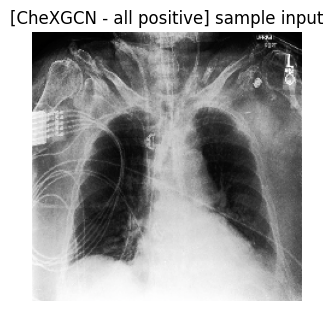


=== Chest X-ray Diagnostic Report [CheXGCN - one positive] ===
  Cardiomegaly         prob= 37.2%  threshold=0.38  predicted=negative  ground_truth=negative  [match]
  Edema                prob= 48.8%  threshold=0.38  predicted=POSITIVE  ground_truth=POSITIVE  [match]
  Pleural Effusion     prob= 47.8%  threshold=0.38  predicted=POSITIVE  ground_truth=negative  [MISMATCH]


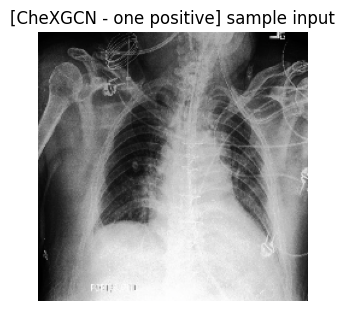

In [18]:
# Stage 4 output (d): sample diagnostic report (same fixed sample images)
generate_sample_report(gcn_forward, model_chexgcn, sampleA_image_tensor, sampleA_true_labels,
                        chexgcn_thresholds, "CheXGCN - all positive", rgb_image=sampleA_rgb_image)
generate_sample_report(gcn_forward, model_chexgcn, sampleB_image_tensor, sampleB_true_labels,
                        chexgcn_thresholds, "CheXGCN - one positive", rgb_image=sampleB_rgb_image)

100%|██████████| 64/64 [00:03<00:00, 18.90it/s]


[CheXGCN - all positive] Cardiomegaly: min=0.0000 max=1.0000 mean=0.3283


100%|██████████| 64/64 [00:03<00:00, 19.23it/s]


[CheXGCN - all positive] Edema: min=0.0000 max=1.0000 mean=0.3656


100%|██████████| 64/64 [00:03<00:00, 19.06it/s]


[CheXGCN - all positive] Pleural Effusion: min=0.0000 max=1.0000 mean=0.3395


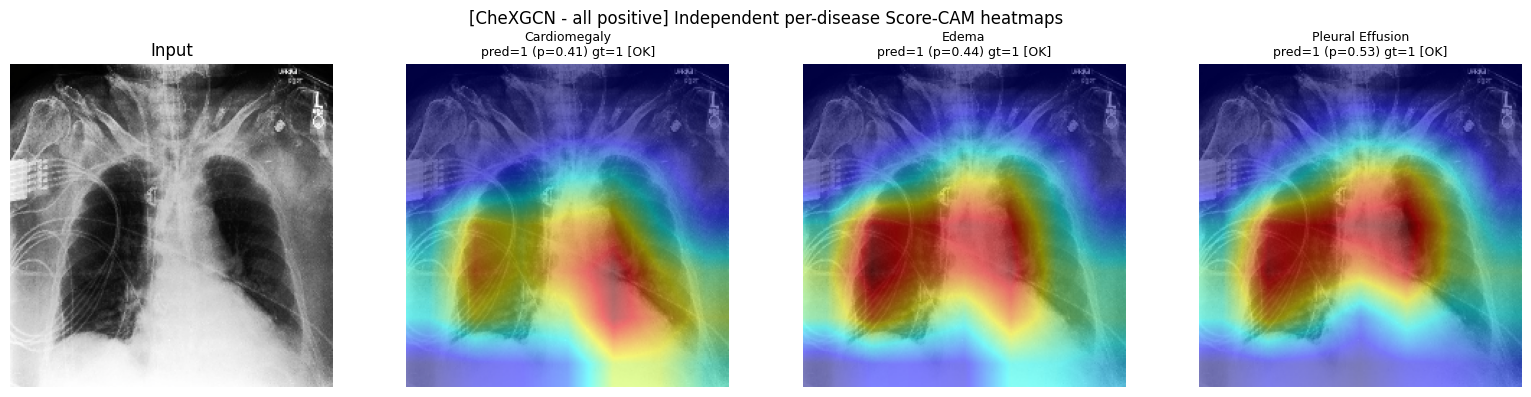

100%|██████████| 64/64 [00:03<00:00, 18.97it/s]


[CheXGCN - one positive] Cardiomegaly: min=0.0000 max=1.0000 mean=0.2652


100%|██████████| 64/64 [00:03<00:00, 18.89it/s]


[CheXGCN - one positive] Edema: min=0.0000 max=1.0000 mean=0.2470


100%|██████████| 64/64 [00:03<00:00, 18.79it/s]


[CheXGCN - one positive] Pleural Effusion: min=0.0000 max=1.0000 mean=0.2553


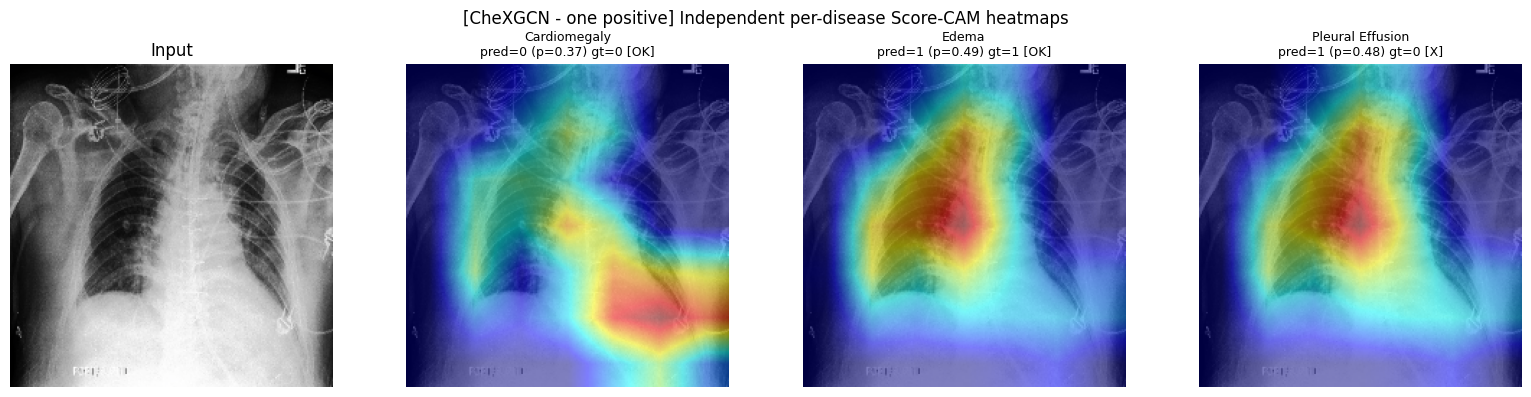

In [19]:
# Stage 4 output (e): per-disease Score-CAM heatmaps.
# CheXGCN.forward(x, adj) needs TWO arguments, but ScoreCAM calls model(x) with only one --
# so we wrap it in a single-argument adapter module that fixes `adj` to adjacency_norm.
# This wrapper is used ONLY for generating heatmaps; training/evaluation above always used the
# real 2-argument model via gcn_forward, so this does not change any trained weights or metrics.
class CheXGCNCamWrapper(nn.Module):
    def __init__(self, model, adj):
        super().__init__()
        self.model = model
        self.adj = adj
    def forward(self, x):
        return self.model(x, self.adj)

chexgcn_cam_model = CheXGCNCamWrapper(model_chexgcn, adjacency_norm).to(device)
chexgcn_target_layer = model_chexgcn.backbone.norm5

score_cam_per_disease(chexgcn_cam_model, chexgcn_target_layer, sampleA_input_tensor, sampleA_rgb_image,
                       "CheXGCN - all positive", sampleA_true_labels, chexgcn_thresholds)
score_cam_per_disease(chexgcn_cam_model, chexgcn_target_layer, sampleB_input_tensor, sampleB_rgb_image,
                       "CheXGCN - one positive", sampleB_true_labels, chexgcn_thresholds)